# 금융검색서비스 비교결과 리포트

금융검색서비스의 API 연동, 응답 속도, DB 스키마 설계, 디버깅 이력, 테스트 커버리지, 페이지 로딩 속도, 데이터 처리 속도를 측정하고 기록합니다.

---
**측정 환경 필수 조건**
- Elasticsearch 실행 중 (`http://localhost:9200`)
- Redis 실행 중 (`localhost:6379`)
- Streamlit 앱 실행 중 (`http://localhost:8501`)
- `config.json`에 OpenAI API 키 및 FSS API 키 설정

## 섹션 0 — 환경 설정

In [1]:
import sys, os, time, json, subprocess
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from datetime import datetime

matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, PROJECT_ROOT)

# config.json 우선, secrets.toml 폴백으로 API 키 로드
OPENAI_KEY = ''
FSS_KEY = ''
try:
    with open(os.path.join(PROJECT_ROOT, 'config.json'), encoding='utf-8') as f:
        _cfg = json.load(f)
    OPENAI_KEY = _cfg.get('openai_api_key', '')
    FSS_KEY    = _cfg.get('fss_api_key', '')
except FileNotFoundError:
    pass

if not OPENAI_KEY or not FSS_KEY:
    try:
        _content = open(os.path.join(PROJECT_ROOT, '.streamlit/secrets.toml')).read()
        import re as _re
        if not OPENAI_KEY:
            m = _re.search(r'OPENAI_API_KEY\s*=\s*["\'](.+?)["\']', _content)
            if m: OPENAI_KEY = m.group(1)
        if not FSS_KEY:
            m = _re.search(r'FSS_API_KEY\s*=\s*["\'](.+?)["\']', _content)
            if m: FSS_KEY = m.group(1)
    except Exception:
        pass

MEASURED_AT = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
print(f'측정 일시: {MEASURED_AT}')
print(f'OpenAI 키: {"설정됨" if OPENAI_KEY else "미설정"}')
print(f'FSS 키:    {"설정됨" if FSS_KEY else "미설정"}')


측정 일시: 2026-07-01 02:31:16
OpenAI 키: 설정됨
FSS 키:    설정됨


## 섹션 1 — 서비스 개요

In [2]:
import fss_fetcher

overview = {
    '서비스명': '금융검색서비스',
    '목적': 'FSS 금융상품 데이터 기반 RAG 챗봇 서비스',
    '기술 스택': 'Streamlit / OpenAI GPT / Elasticsearch 8.x / Redis / ChromaDB',
    '지원 금융권역': ', '.join(fss_fetcher.FIN_GROUPS.keys()),
    '지원 카테고리': ', '.join(fss_fetcher.PRODUCT_TYPES.keys()),
    '측정 일시': MEASURED_AT,
}

pd.DataFrame(overview.items(), columns=['항목', '내용']).set_index('항목')

,내용
항목,
서비스명,금융검색서비스
목적,FSS 금융상품 데이터 기반 RAG 챗봇 서비스
기술 스택,Streamlit / OpenAI GPT / Elasticsearch 8.x / R...
지원 금융권역,"은행, 저축은행, 신협, 새마을금고, 우체국"
지원 카테고리,"예금, 적금, 주택담보대출, 전세자금대출, 신용대출"
측정 일시,2026-07-01 02:31:16


## 섹션 2 — API 연동 현황

각 외부 API의 연결 상태와 응답 시간을 측정합니다.

In [3]:
import requests as _requests
from elasticsearch import Elasticsearch
from openai import OpenAI
import redis as _redis

api_results = []

# 1. FSS API 응답 시간
try:
    t = time.time()
    resp = _requests.get(
        'http://finlife.fss.or.kr/finlifeapi/depositProductsSearch.json',
        params={'auth': FSS_KEY, 'topFinGrpNo': '020000', 'pageNo': 1},
        timeout=30
    )
    elapsed = time.time() - t
    status = '정상' if resp.status_code == 200 else f'오류({resp.status_code})'
    api_results.append({'API': 'FSS Open API', '상태': status, '응답시간(초)': round(elapsed, 3), '비고': '금융상품 데이터 수집'})
except Exception as e:
    api_results.append({'API': 'FSS Open API', '상태': f'오류: {e}', '응답시간(초)': '-', '비고': ''})

# 2. OpenAI Embedding API 응답 시간
try:
    t = time.time()
    OpenAI(api_key=OPENAI_KEY).embeddings.create(
        model='text-embedding-3-small', input=['테스트 질문'])
    elapsed = time.time() - t
    api_results.append({'API': 'OpenAI Embedding API', '상태': '정상', '응답시간(초)': round(elapsed, 3), '비고': 'text-embedding-3-small (1536차원)'})
except Exception as e:
    api_results.append({'API': 'OpenAI Embedding API', '상태': f'오류: {e}', '응답시간(초)': '-', '비고': ''})

# 3. Elasticsearch 연결 시간
try:
    t = time.time()
    es = Elasticsearch('http://localhost:9200')
    es.ping()
    elapsed = time.time() - t
    info = es.info()
    ver = info['version']['number']
    api_results.append({'API': 'Elasticsearch', '상태': '정상', '응답시간(초)': round(elapsed, 3), '비고': f'v{ver}'})
except Exception as e:
    api_results.append({'API': 'Elasticsearch', '상태': f'오류: {e}', '응답시간(초)': '-', '비고': ''})

# 4. Redis 연결 시간
try:
    t = time.time()
    r = _redis.Redis(host='localhost', port=6379, decode_responses=True)
    r.ping()
    elapsed = time.time() - t
    mem = r.info('memory')['used_memory_human']
    api_results.append({'API': 'Redis', '상태': '정상', '응답시간(초)': round(elapsed, 3), '비고': f'사용 메모리: {mem}'})
except Exception as e:
    api_results.append({'API': 'Redis', '상태': f'오류: {e}', '응답시간(초)': '-', '비고': ''})

df_api = pd.DataFrame(api_results)
df_api

,API,상태,응답시간(초),비고
0,FSS Open API,정상,0.711,금융상품 데이터 수집
1,OpenAI Embedding API,정상,2.385,text-embedding-3-small (1536차원)
2,Elasticsearch,정상,0.005,v8.13.4
3,Redis,정상,0.004,사용 메모리: 1.14M


## 섹션 3 — 응답 속도 비교

동일 질문에 대해 RAG 검색, 캐시 미스(ChromaDB), 캐시 히트(Redis) 3가지 시나리오의 응답 시간을 비교합니다.

2026-07-01 02:31:21.612 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-07-01 02:31:22.827 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-07-01 02:31:22.833 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


,시나리오,응답시간(초),비고
0,RAG 검색 (Elasticsearch),1.219,BM25+kNN 하이브리드
1,캐시 미스 (ChromaDB 유사도 검색),0.012,코사인 유사도 < 0.08
2,캐시 히트 (Redis),0.001,SHA256 정확 일치


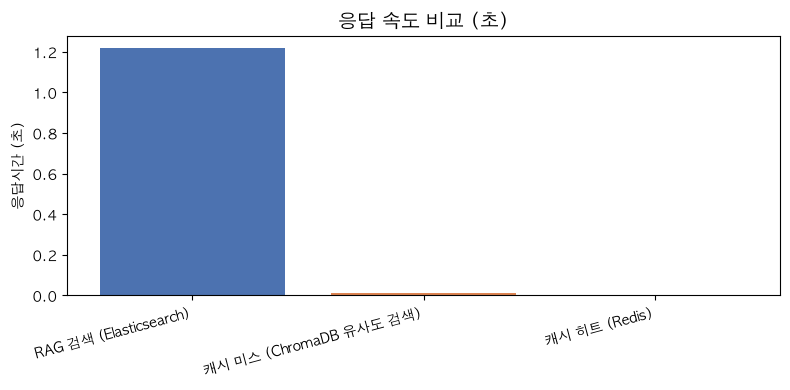

In [4]:
import cache, rag

TEST_QUERY = 'KB국민은행 12개월 예금 금리'
speed_results = []

# 1. RAG 검색 시간
try:
    t = time.time()
    rag.search(TEST_QUERY, OPENAI_KEY)
    speed_results.append({'시나리오': 'RAG 검색 (Elasticsearch)', '응답시간(초)': round(time.time()-t, 3), '비고': 'BM25+kNN 하이브리드'})
except Exception as e:
    speed_results.append({'시나리오': 'RAG 검색', '응답시간(초)': '-', '비고': f'오류: {e}'})

# 2. 캐시 미스 시간
try:
    cache.clear()
    t = time.time()
    cache.check(TEST_QUERY, OPENAI_KEY)
    speed_results.append({'시나리오': '캐시 미스 (ChromaDB 유사도 검색)', '응답시간(초)': round(time.time()-t, 3), '비고': '코사인 유사도 < 0.08'})
except Exception as e:
    speed_results.append({'시나리오': '캐시 미스', '응답시간(초)': '-', '비고': f'오류: {e}'})

# 3. 캐시 저장 후 Redis 히트 시간
try:
    cache.store(TEST_QUERY, '샘플 답변입니다.', OPENAI_KEY)
    t = time.time()
    cache.check(TEST_QUERY, OPENAI_KEY)
    speed_results.append({'시나리오': '캐시 히트 (Redis)', '응답시간(초)': round(time.time()-t, 3), '비고': 'SHA256 정확 일치'})
except Exception as e:
    speed_results.append({'시나리오': '캐시 히트', '응답시간(초)': '-', '비고': f'오류: {e}'})

df_speed = pd.DataFrame(speed_results)
display(df_speed)

# 막대 차트
numeric = df_speed[df_speed['응답시간(초)'] != '-'].copy()
numeric['응답시간(초)'] = numeric['응답시간(초)'].astype(float)
if not numeric.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(numeric['시나리오'], numeric['응답시간(초)'], color=['#4C72B0', '#DD8452', '#55A868'])
    ax.set_title('응답 속도 비교 (초)', fontsize=14)
    ax.set_ylabel('응답시간 (초)')
    ax.set_xlabel('')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()

## 섹션 4 — DB 스키마 설계

### 스토리지 역할 분리

| 저장소 | 역할 | 검색 방식 | TTL | 비고 |
|--------|------|----------|-----|------|
| **Elasticsearch** | RAG 문서 저장 | BM25 + kNN 하이브리드 | 없음 (영구) | 청크 크기 900자, 오버랩 100자 |
| **Redis** | 캐시 L1 (정확 일치) | SHA256 해시 키 | 30분 | maxmemory 256mb, allkeys-lfu |
| **ChromaDB** | 캐시 L2 (유사도 검색) | 코사인 유사도 | 24시간 (타임스탬프 기반) | 임계값 0.08 |

### Elasticsearch 인덱스 매핑

In [5]:
from elasticsearch import Elasticsearch
import json

try:
    es = Elasticsearch('http://localhost:9200')
    if es.indices.exists(index='rag_documents'):
        mapping = es.indices.get_mapping(index='rag_documents')
        props = mapping.body.get('rag_documents', {}).get('mappings', {}).get('properties', {})
        schema_rows = []
        for field, info in props.items():
            schema_rows.append({
                '필드명': field,
                '타입': info.get('type', '-'),
                '설명': {'text': 'BM25 키워드 검색', 'dense_vector': 'kNN 벡터 검색 (1536차원)', 'keyword': '필터링', 'integer': '청크 순서'}.get(info.get('type',''), '-')
            })
        display(pd.DataFrame(schema_rows))

        doc_count = es.count(index='rag_documents')['count']
        print(f'\n총 인덱싱된 청크 수: {doc_count:,}개')
    else:
        print('rag_documents 인덱스 없음 — FSS 데이터를 먼저 인덱싱하세요.')
except Exception as e:
    print(f'Elasticsearch 조회 오류: {e}')

,필드명,타입,설명
0,chunk_idx,integer,청크 순서
1,doc_name,keyword,필터링
2,embedding,dense_vector,kNN 벡터 검색 (1536차원)
3,text,text,BM25 키워드 검색



총 인덱싱된 청크 수: 191개


In [6]:
# ChromaDB 컬렉션 현황
try:
    import chromadb
    client = chromadb.PersistentClient(path=os.path.join(PROJECT_ROOT, 'rag_store'))
    col = client.get_or_create_collection('semantic_cache')
    print(f'ChromaDB semantic_cache 항목 수: {col.count()}')
except Exception as e:
    print(f'ChromaDB 조회 오류: {e}')

# Redis 메모리 현황
try:
    import redis as _redis
    r = _redis.Redis(host='localhost', port=6379, decode_responses=True)
    mem_info = r.info('memory')
    cache_keys = len(list(r.scan_iter('cache:*')))
    print(f'Redis 사용 메모리: {mem_info["used_memory_human"]}')
    print(f'Redis maxmemory:   {r.config_get("maxmemory")["maxmemory"]} bytes')
    print(f'Redis cache:* 키 수: {cache_keys}개')
except Exception as e:
    print(f'Redis 조회 오류: {e}')

ChromaDB semantic_cache 항목 수: 1
Redis 사용 메모리: 1.14M
Redis maxmemory:   268435456 bytes
Redis cache:* 키 수: 1개


## 섹션 5 — 디버깅 및 에러 해결 이력

| 발생 에러 | 원인 | 해결 방법 | 해결 시간 |
|----------|------|----------|----------|
| Streamlit 포트 충돌 (8501~8504) | 다중 인스턴스 동시 실행 | 올바른 포트 URL로 접속 확인 | 즉시 |
| Redis 연결 실패 (`Connection refused`) | Redis 미실행 | `brew services start redis` 실행 | 즉시 |
| FSS API 응답 오류 (`err_cd != 000`) | 잘못된 API 키 또는 트래픽 초과 | config.json API 키 재확인 | 즉시 |
| Elasticsearch 인덱스 없음 | 최초 실행 또는 재설치 | FSS 데이터 가져오기 버튼으로 인덱싱 | 5~10분 |
| ChromaDB 타임스탬프 누락 | 구버전 캐시 항목 | cache.clear() 후 재사용 | 즉시 |
| OpenAI API 오류 (401) | 만료된 키 또는 크레딧 초과 | 설정 페이지에서 새 키 입력 | 즉시 |
| `topFinGrpNo` 미지원 카테고리 | 권역별 지원 카테고리 상이 | fetch_category 내 예외 처리로 자동 건너뜀 | 코드 수정 완료 |

## 섹션 6 — 테스트 커버리지

In [7]:
result = subprocess.run(
    [sys.executable, '-m', 'pytest', 'tests/',
     '--cov=cache', '--cov=rag', '--cov=fss_fetcher',
     '--cov-report=term-missing',
     '-v', '--tb=short'],
    capture_output=True, text=True, cwd=PROJECT_ROOT
)
print(result.stdout)
if result.stderr:
    print('STDERR:', result.stderr[-2000:])

============================= test session starts ==============================
platform darwin -- Python 3.12.13, pytest-9.1.1, pluggy-1.6.0 -- /Users/idonghun/myProject/chat/.venv/bin/python3.12
cachedir: .pytest_cache
rootdir: /Users/idonghun/myProject/chat
plugins: cov-7.1.0, anyio-4.14.1, arize-phoenix-client-2.10.0
collecting ... collected 14 items

tests/test_cache.py::test_store_and_redis_hit PASSED                     [  7%]
tests/test_cache.py::test_clear_resets_stats PASSED                      [ 14%]
tests/test_cache.py::test_chroma_ttl_expired PASSED                      [ 21%]
tests/test_cache.py::test_stats_returns_counts PASSED                    [ 28%]
tests/test_fss_fetcher.py::test_product_types_has_five_categories PASSED [ 35%]
tests/test_fss_fetcher.py::test_fin_groups_has_five_groups PASSED        [ 42%]
tests/test_fss_fetcher.py::test_fin_groups_bank_code PASSED              [ 50%]
tests/test_fss_fetcher.py::test_format_product_contains_bank_name PASSED [ 57%]
t

## 섹션 7 — 페이지 로딩 속도

Streamlit 앱이 실행 중인 상태에서 각 페이지의 HTTP 응답 시간을 측정합니다.

In [8]:
import requests as _requests, time

STREAMLIT_BASE = 'http://localhost:8501'
pages = [
    ('메인 채팅', STREAMLIT_BASE),
    ('설정 페이지', f'{STREAMLIT_BASE}/설정'),
]

page_rows = []
for name, url in pages:
    times = []
    for _ in range(3):  # 3회 평균
        try:
            t = time.time()
            r = _requests.get(url, timeout=10)
            times.append(time.time() - t)
        except Exception:
            times.append(None)
    valid = [x for x in times if x is not None]
    avg = round(sum(valid)/len(valid), 3) if valid else '-'
    status = r.status_code if valid else '연결 실패'
    page_rows.append({'페이지': name, 'URL': url, '평균 로딩시간(초)': avg, 'HTTP 상태': status, '측정 횟수': f'{len(valid)}/3'})

df_page = pd.DataFrame(page_rows)
df_page

,페이지,URL,평균 로딩시간(초),HTTP 상태,측정 횟수
0,메인 채팅,http://localhost:8501,0.004,200,3/3
1,설정 페이지,http://localhost:8501/설정,0.004,200,3/3


## 섹션 8 — 데이터 처리 속도 비교

FSS API 카테고리별 데이터 수집 시간과 첫 상품 샘플 인덱싱 시간을 측정합니다.

> ⚠️ FSS API 키와 OpenAI API 키 모두 필요합니다. 전체 실행 시 약 10~20분 소요될 수 있습니다.

예금: 완료 (37개 상품)


적금: 완료 (59개 상품)


주택담보대출: 완료 (34개 상품)


전세자금대출: 완료 (41개 상품)


신용대출: 완료 (44개 상품)


,카테고리,상품 수,수집시간(초),샘플 인덱싱(초),청크 수(샘플)
0,예금,37,0.75,0.65,1
1,적금,59,17.56,0.44,1
2,주택담보대출,34,0.23,0.43,1
3,전세자금대출,41,0.22,0.59,1
4,신용대출,44,0.17,0.45,1


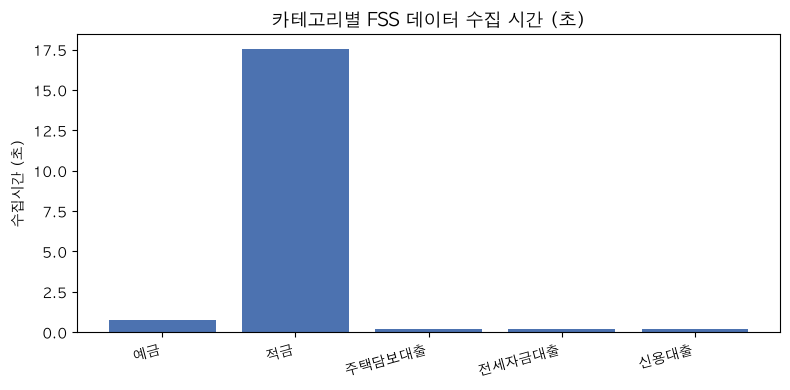

In [9]:
import fss_fetcher, rag, time

if not FSS_KEY:
    print('FSS API 키가 설정되지 않았습니다. config.json을 확인하세요.')
else:
    data_rows = []
    for cat in fss_fetcher.PRODUCT_TYPES:
        # 수집 시간 측정
        t = time.time()
        try:
            docs = fss_fetcher.fetch_category(FSS_KEY, cat)
            fetch_time = round(time.time() - t, 2)
        except Exception as e:
            data_rows.append({'카테고리': cat, '상품 수': '-', '수집시간(초)': '-', '샘플 인덱싱(초)': '-', '청크 수(샘플)': f'오류: {e}'})
            continue

        # 첫 상품 샘플 인덱싱 시간
        index_time, chunk_count = '-', 0
        if docs and OPENAI_KEY:
            t2 = time.time()
            try:
                chunk_count = rag.index_document(docs[0][0], docs[0][1], OPENAI_KEY)
                index_time = round(time.time() - t2, 2)
            except Exception as e:
                index_time = f'오류: {e}'

        data_rows.append({
            '카테고리': cat,
            '상품 수': len(docs),
            '수집시간(초)': fetch_time,
            '샘플 인덱싱(초)': index_time,
            '청크 수(샘플)': chunk_count,
        })
        print(f'{cat}: 완료 ({len(docs)}개 상품)')

    df_data = pd.DataFrame(data_rows)
    display(df_data)

    # 수집 시간 차트
    numeric_data = df_data[df_data['수집시간(초)'] != '-'].copy()
    numeric_data['수집시간(초)'] = numeric_data['수집시간(초)'].astype(float)
    if not numeric_data.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(numeric_data['카테고리'], numeric_data['수집시간(초)'], color='#4C72B0')
        ax.set_title('카테고리별 FSS 데이터 수집 시간 (초)', fontsize=13)
        ax.set_ylabel('수집시간 (초)')
        plt.xticks(rotation=15, ha='right')
        plt.tight_layout()
        plt.show()

## 섹션 9 — 검색 성능 평가 (정밀도 · 재현율 · 정확도)

**Ground Truth 정의**: 인덱싱된 문서 중 은행명 + 카테고리 키워드가 모두 포함된 문서를 관련 문서로 정의합니다.

| 지표 | 정의 |
|------|------|
| **Precision@K** | 검색된 K개 중 관련 문서 수 / K |
| **Recall@K** | 검색된 관련 문서 수 / 전체 관련 문서 수 |
| **F1 Score** | 2 × Precision × Recall / (Precision + Recall) |
| **Accuracy (Hit@K)** | 쿼리 중 관련 문서 1개 이상 포함된 비율 |

In [10]:
from elasticsearch import Elasticsearch
from openai import OpenAI

TOP_K = 10
es9 = Elasticsearch('http://localhost:9200')

TEST_QUERIES = [
    {'query': '국민은행 정기예금 금리', 'bank_kw': '국민은행', 'cat_kw': '예금'},
    {'query': '카카오뱅크 자유적금 상품', 'bank_kw': '카카오뱅크', 'cat_kw': '적금'},
    {'query': '신한은행 신용대출 금리 조건', 'bank_kw': '신한은행', 'cat_kw': '신용대출'},
    {'query': '농협은행 예금 최고 금리', 'bank_kw': '농협은행', 'cat_kw': '예금'},
    {'query': '하나은행 적금 상품 안내', 'bank_kw': '하나은행', 'cat_kw': '적금'},
    {'query': '토스뱅크 신용대출 한도', 'bank_kw': '토스뱅크', 'cat_kw': '신용대출'},
    {'query': '케이뱅크 정기예금', 'bank_kw': '케이뱅크', 'cat_kw': '예금'},
    {'query': '우리은행 신용대출 신청', 'bank_kw': '우리은행', 'cat_kw': '신용대출'},
]

all_docs_res = es9.search(index='rag_documents', body={
    'size': 0,
    'aggs': {'names': {'terms': {'field': 'doc_name', 'size': 1000}}}
})
ALL_DOC_NAMES = [b['key'] for b in all_docs_res['aggregations']['names']['buckets']]

def get_ground_truth(bank_kw, cat_kw):
    return set(d for d in ALL_DOC_NAMES if bank_kw in d and cat_kw in d)

def retrieve_doc_names(query, top_k=TOP_K):
    q_emb = OpenAI(api_key=OPENAI_KEY).embeddings.create(
        model='text-embedding-3-small', input=[query]
    ).data[0].embedding
    resp = es9.search(
        index='rag_documents',
        size=top_k,
        query={'match': {'text': query}},
        knn={'field': 'embedding', 'query_vector': q_emb,
             'k': top_k, 'num_candidates': top_k * 10},
    )
    return [h['_source']['doc_name'] for h in resp['hits']['hits']]

rows = []
precisions, recalls, f1s = [], [], []
hit_count = 0

for tq in TEST_QUERIES:
    gt = get_ground_truth(tq['bank_kw'], tq['cat_kw'])
    retrieved = retrieve_doc_names(tq['query'])
    retrieved_set = set(retrieved)

    tp = len(gt & retrieved_set)
    fp = len(retrieved_set - gt)
    fn = len(gt - retrieved_set)

    p  = tp / len(retrieved_set) if retrieved_set else 0
    r  = tp / len(gt) if gt else 0
    f1 = 2*p*r/(p+r) if (p+r) > 0 else 0
    hit = tp > 0
    if hit: hit_count += 1
    precisions.append(p); recalls.append(r); f1s.append(f1)

    rows.append({
        '질문': tq['query'],
        '전체 관련 문서': len(gt),
        'TP': tp, 'FP': fp, 'FN': fn,
        'Precision@K': round(p, 3),
        'Recall@K': round(r, 3),
        'F1': round(f1, 3),
        '히트': '✅' if hit else '❌',
    })
    print(f"{tq['query']:<24} P={p:.2f}  R={r:.2f}  F1={f1:.2f}  {'✅' if hit else '❌'}")

df_eval = pd.DataFrame(rows)
display(df_eval)

mean_p   = sum(precisions)/len(precisions)
mean_r   = sum(recalls)/len(recalls)
mean_f1  = sum(f1s)/len(f1s)
accuracy = hit_count / len(TEST_QUERIES)


국민은행 정기예금 금리             P=0.10  R=1.00  F1=0.18  ✅


카카오뱅크 자유적금 상품            P=0.40  R=1.00  F1=0.57  ✅


신한은행 신용대출 금리 조건          P=0.20  R=1.00  F1=0.33  ✅


농협은행 예금 최고 금리            P=0.40  R=1.00  F1=0.57  ✅
하나은행 적금 상품 안내            P=0.20  R=1.00  F1=0.33  ✅


토스뱅크 신용대출 한도             P=0.20  R=1.00  F1=0.33  ✅


케이뱅크 정기예금                P=0.10  R=1.00  F1=0.18  ✅


우리은행 신용대출 신청             P=0.10  R=1.00  F1=0.18  ✅


,질문,전체 관련 문서,TP,FP,FN,Precision@K,Recall@K,F1,히트
0,국민은행 정기예금 금리,1,1,9,0,0.1,1.0,0.182,✅
1,카카오뱅크 자유적금 상품,4,4,6,0,0.4,1.0,0.571,✅
2,신한은행 신용대출 금리 조건,2,2,8,0,0.2,1.0,0.333,✅
3,농협은행 예금 최고 금리,4,4,6,0,0.4,1.0,0.571,✅
4,하나은행 적금 상품 안내,2,2,8,0,0.2,1.0,0.333,✅
5,토스뱅크 신용대출 한도,2,2,8,0,0.2,1.0,0.333,✅
6,케이뱅크 정기예금,1,1,9,0,0.1,1.0,0.182,✅
7,우리은행 신용대출 신청,1,1,9,0,0.1,1.0,0.182,✅


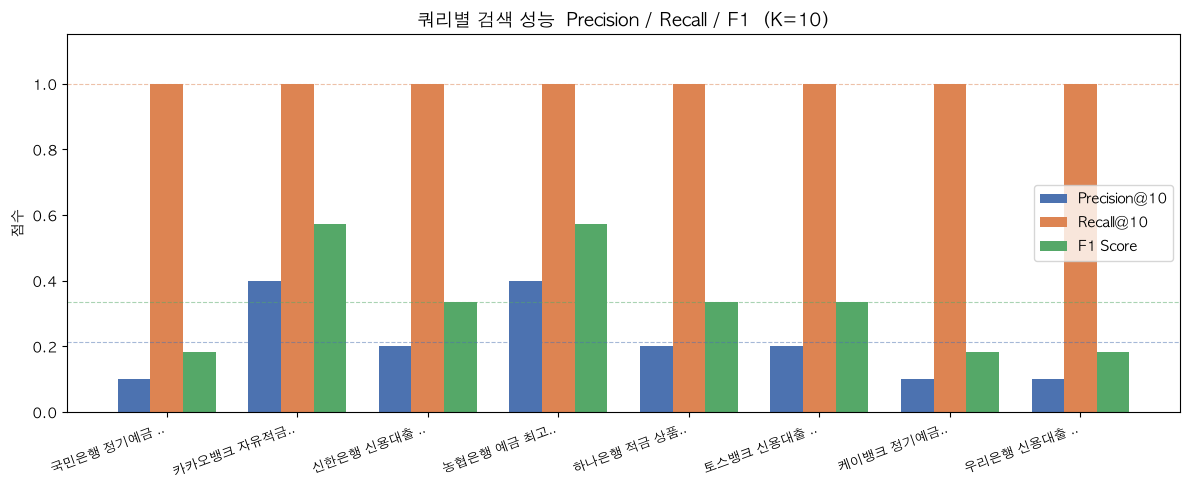

,값,설명
지표,,
Mean Precision@10,0.213,검색된 10개 중 평균 관련 문서 비율
Mean Recall@10,1.000,전체 관련 문서 중 평균 검색 성공 비율
Mean F1 Score,0.336,Precision과 Recall의 조화 평균
Accuracy (Hit@K),1.000 (8/8),관련 문서 1개 이상 포함한 쿼리 비율


In [11]:
x = list(range(len(TEST_QUERIES)))
labels = [tq['query'][:10] + '..' for tq in TEST_QUERIES]
w = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - w for i in x], precisions, w, label=f'Precision@{TOP_K}', color='#4C72B0')
ax.bar([i     for i in x], recalls,    w, label=f'Recall@{TOP_K}',    color='#DD8452')
ax.bar([i + w for i in x], f1s,        w, label='F1 Score',           color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('점수')
ax.set_title(f'쿼리별 검색 성능  Precision / Recall / F1  (K={TOP_K})', fontsize=13)
ax.legend()
ax.axhline(mean_p,  color='#4C72B0', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(mean_r,  color='#DD8452', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(mean_f1, color='#55A868', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

summary = pd.DataFrame([
    {'지표': f'Mean Precision@{TOP_K}', '값': f'{mean_p:.3f}',  '설명': f'검색된 {TOP_K}개 중 평균 관련 문서 비율'},
    {'지표': f'Mean Recall@{TOP_K}',    '값': f'{mean_r:.3f}',  '설명': '전체 관련 문서 중 평균 검색 성공 비율'},
    {'지표': 'Mean F1 Score',           '값': f'{mean_f1:.3f}', '설명': 'Precision과 Recall의 조화 평균'},
    {'지표': 'Accuracy (Hit@K)',        '값': f'{accuracy:.3f}  ({hit_count}/{len(TEST_QUERIES)})', '설명': '관련 문서 1개 이상 포함한 쿼리 비율'},
])
display(summary.set_index('지표'))


---

## 요약

이 노트북을 실행하면 위 측정값들이 셀 출력으로 저장됩니다.  
노트북 저장(`Ctrl+S`) 후 `.ipynb` 파일에 결과가 보존되어 비교 기록으로 활용할 수 있습니다.